# Black Friday

> What is black friday?

Black Friday refers to the Friday following Thanksgiving in the United States, which marks the unofficial beginning of the holiday shopping season. It is globally known for massive promotional sales, deep retail discounts, and enormous crowds of consumers.

#### About Datasets :
This file contains 100,000 retail transaction records capturing customer purchasing behavior during Black Friday and promotional sales events.

Each row represents a single purchase and includes information about customer demographics, product category, pricing, discounts, quantity, and final transaction value.

The dataset combines transactional, pricing, and behavioral attributes, making it suitable for analyzing how discounts, customer segments, and product categories influence purchasing decisions during high-demand retail periods.

It is structured to support both exploratory data analysis and machine learning workflows, enabling users to study sales patterns, customer behavior, and revenue trends.

Data source : https://www.kaggle.com/datasets/noopurbhatt/retail-black-friday-sales-dataset/data



## Main Question

How do discounts, customer segments, product categories, and purchase timing influence sales performance during the Black Friday promotional period?

In [1]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noopurbhatt/retail-black-friday-sales-dataset")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\noopurbhatt\retail-black-friday-sales-dataset\versions\1


['retail_black_friday_sales_100k.csv']

In [3]:
df = pd.read_csv(os.path.join(path, 'retail_black_friday_sales_100k.csv'))

## Chapter 1 : Data Overview

In [4]:
df.rename(columns={'purchase_date': 'date'}, inplace=True)
df['date'] = (pd.to_datetime(df['date'])
              + pd.to_timedelta(df['purchase_hour'], unit='h')
              )
cols = ['date'] + [col for col in df.columns if col != 'date']
df = df[cols]


df = df.sort_values('date')

df.head()

,date,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_hour,is_weekend,is_black_friday
75143,2025-11-24,T0075144,C006682,46-55,Female,Houston,Returning,P6651,Footwear,80.83,35,52.54,1,52.54,Mobile Wallet,0,0,0
40042,2025-11-24,T0040043,C005592,18-25,Male,Miami,Returning,P2334,Toys,31.36,5,29.79,1,29.79,Debit Card,0,0,0
54040,2025-11-24,T0054041,C015267,26-35,Female,Seattle,Loyal,P9781,Accessories,104.88,30,73.42,1,73.42,Credit Card,0,0,0
75827,2025-11-24,T0075828,C016258,36-45,Female,Miami,Returning,P2355,Footwear,325.79,10,293.21,1,293.21,Mobile Wallet,0,0,0
54123,2025-11-24,T0054124,C006349,18-25,Female,Atlanta,New,P9520,Accessories,436.15,5,414.34,1,414.34,Cash,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 75143 to 36194
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              100000 non-null  datetime64[us]
 1   transaction_id    100000 non-null  str           
 2   customer_id       100000 non-null  str           
 3   age_group         100000 non-null  str           
 4   gender            100000 non-null  str           
 5   city              100000 non-null  str           
 6   customer_segment  100000 non-null  str           
 7   product_id        100000 non-null  str           
 8   product_category  100000 non-null  str           
 9   original_price    100000 non-null  float64       
 10  discount_pct      100000 non-null  int64         
 11  final_price       100000 non-null  float64       
 12  quantity          100000 non-null  int64         
 13  purchase_amount   100000 non-null  float64       
 14  payment_method   

In [6]:
start_date = df['date'].min().date()
end_date = df['date'].max().date()
total_days = total_days = df['date'].dt.date.nunique()

print("\t",15*"="," DATA OVERVIEW ", 15*"=")

overview = pd.DataFrame({
    "Metric": [
        "Date Range",
        "Total Days",
        "Total Transactions",
        "Unique Customers",
        "Unique Products",
        "Total Revenue",
        "Average Transaction",
        "Mean Original Price",
        "Mean Final Price",
        "Mean Discount (%)",
        "Max Discount (%)",
        "Mean Quantity",
        "Total Items Sold",
        "Highest Purchase",
        "Lowest Purchase"
    ],
    "Value": [
        f"{start_date} -> {end_date}",
        total_days,
        len(df),
        df['customer_id'].nunique(),
        df['product_id'].nunique(),
        round(df['purchase_amount'].sum(), 2),
        round(df['purchase_amount'].mean(), 2),
        round(df['original_price'].mean(), 2),
        round(df['final_price'].mean(), 2),
        round(df['discount_pct'].mean(), 2),
        df['discount_pct'].max(),
        round(df['quantity'].mean(), 2),
        df['quantity'].sum(),
        round(df['purchase_amount'].max(), 2),
        round(df['purchase_amount'].min(), 2)
    ]
})

overview


	 ===============  DATA OVERVIEW  ===============


,Metric,Value
0,Date Range,2025-11-24 -> 2025-12-01
1,Total Days,8
2,Total Transactions,100000
3,Unique Customers,32997
4,Unique Products,9000
5,Total Revenue,35125630.67
6,Average Transaction,351.26
7,Mean Original Price,330.28
8,Mean Final Price,242.22
9,Mean Discount (%),26.63


## Chapter 2 : Data Quality Check

In [7]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index(name='missing_count')
      .rename(columns={'index': 'column'})
)

missing_summary['missing_pct'] = (
    missing_summary['missing_count'] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,column,missing_count,missing_pct
0,date,0,0.0
1,transaction_id,0,0.0
2,customer_id,0,0.0
3,age_group,0,0.0
4,gender,0,0.0
5,city,0,0.0
6,customer_segment,0,0.0
7,product_id,0,0.0
8,product_category,0,0.0
9,original_price,0,0.0


In [8]:
numerical_cols = [
    'original_price',
    'discount_pct',
    'final_price',
    'quantity',
    'purchase_amount',
    'purchase_hour'
]

outlier_summary = []

for col in numerical_cols:

    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'count': len(series),
        'mean': round(series.mean(), 2),
        'median': round(series.median(), 2),
        'min': round(series.min(), 2),
        'max': round(series.max(), 2),
        'iqr_lower_bound': round(lower_bound, 2),
        'iqr_upper_bound': round(upper_bound, 2),
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'outlier_pct',
    ascending=False
)

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
0,original_price,100000,330.28,180.22,5.00,2499.89,-280.27,702.10,11819,11.82
2,final_price,100000,242.22,129.49,2.07,2374.90,-214.01,524.53,11476,11.48
4,purchase_amount,100000,351.26,161.15,2.22,11441.80,-348.71,783.18,10897,10.90
3,quantity,100000,1.45,1.00,1.00,5.00,-0.50,3.50,3979,3.98
1,discount_pct,100000,26.63,25.00,5.00,60.00,-2.50,57.50,1997,2.00
5,purchase_hour,100000,11.48,11.00,0.00,23.00,-13.00,35.00,0,0.00


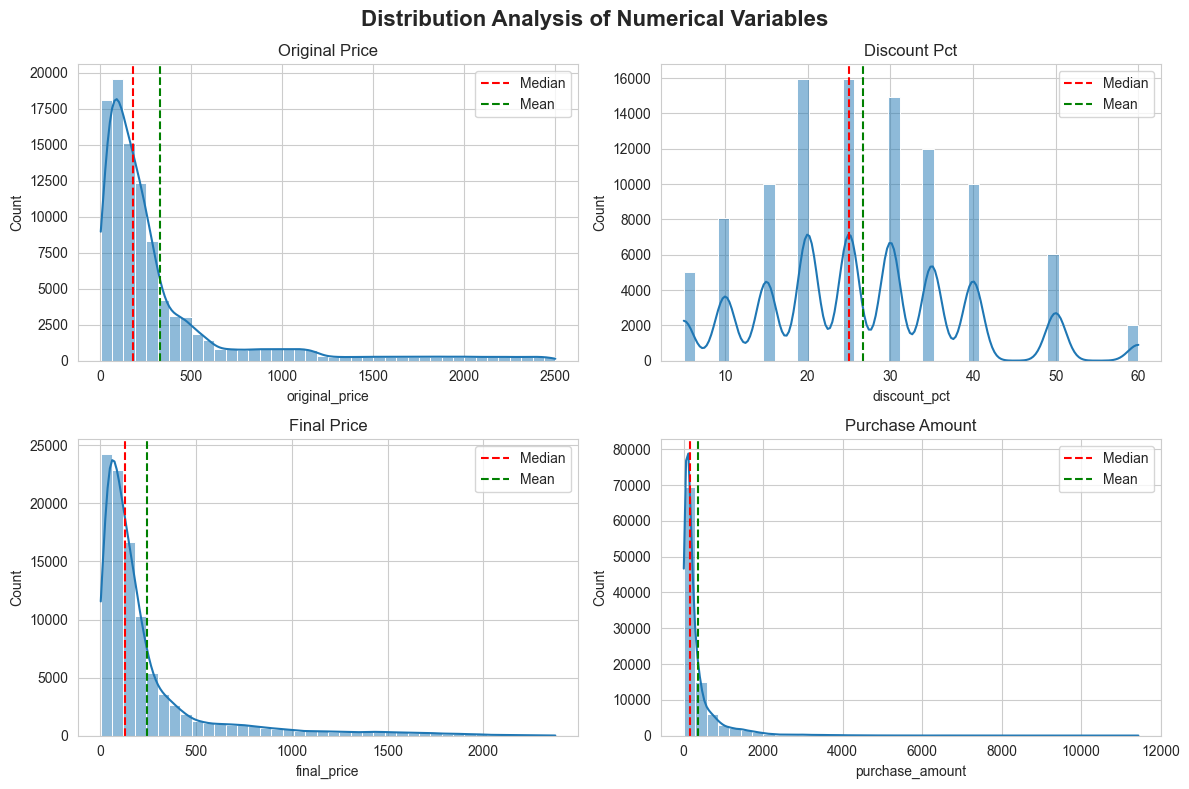

In [9]:
target_columns = [
    'original_price',
    'discount_pct',
    'final_price',
    'purchase_amount'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.axvline(
        df[col].median(),
        color='red',
        linestyle='--',
        label='Median'
    )

    ax.axvline(
        df[col].mean(),
        color='green',
        linestyle='--',
        label='Mean'
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.legend()
    
plt.suptitle(
    'Distribution Analysis of Numerical Variables',
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

## Chapter 3 : Exploration Data Analysis

### 3.1 How did Black Friday affect daily revenue and transaction volume?

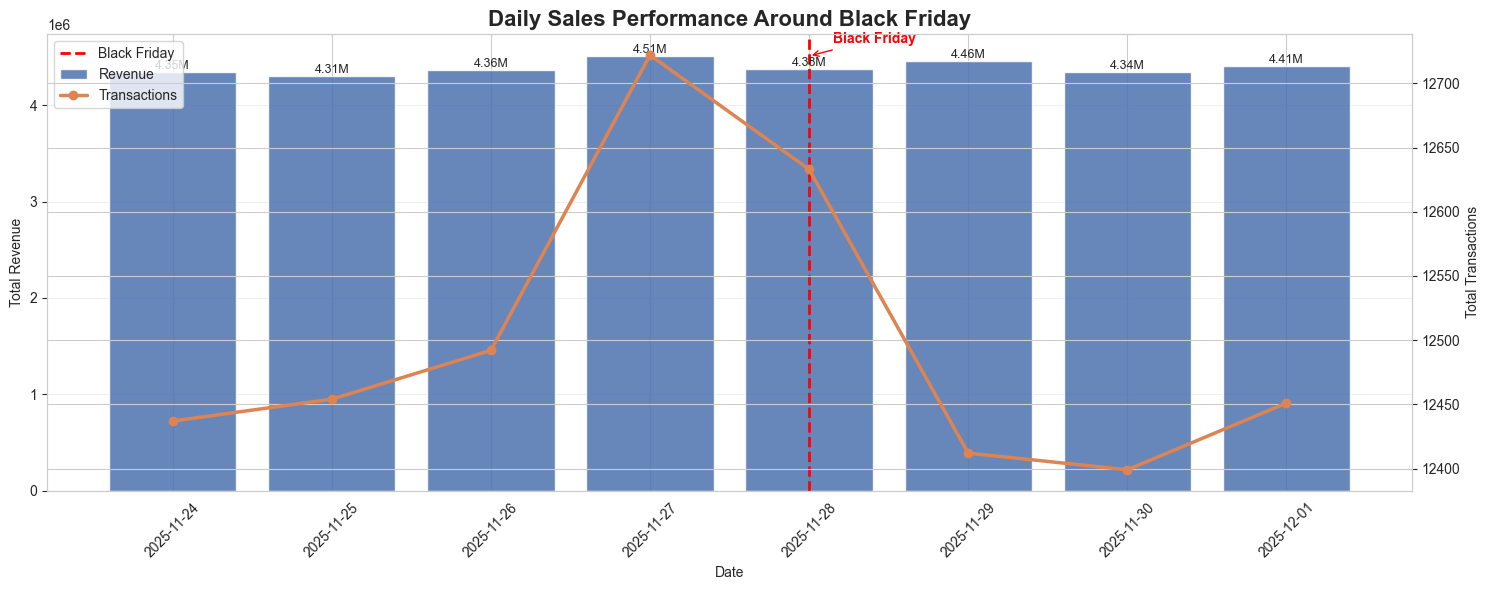

In [10]:
df_daily = (
    df.groupby(pd.Grouper(key='date', freq='D'))
      .agg(
          transactions=('transaction_id', 'count'),
          revenue=('purchase_amount', 'sum'),
          avg_purchase=('purchase_amount', 'mean')
      )
      .reset_index()
)

black_friday_date = df.loc[
    df['is_black_friday'] == 1,
    'date'
].dt.normalize().iloc[0]

x_pos = np.arange(len(df_daily))

black_friday_idx = df_daily.index[
    df_daily['date'] == black_friday_date
][0]

fig, ax1 = plt.subplots(figsize=(15, 6))

bars = ax1.bar(
    x_pos,
    df_daily['revenue'],
    color='#4C72B0',
    alpha=0.85,
    label='Revenue'
)

ax1.set_title(
    'Daily Sales Performance Around Black Friday',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    df_daily['date'].dt.strftime('%Y-%m-%d'),
    rotation=45
)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1_000_000:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    df_daily['transactions'],
    marker='o',
    color='#DD8452',
    linewidth=2.5,
    label='Transactions'
)

ax2.set_ylabel('Total Transactions')

ax1.axvline(
    x=black_friday_idx,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Black Friday'
)

ax1.annotate(
    'Black Friday',
    xy=(black_friday_idx, df_daily['revenue'].max()),
    xytext=(black_friday_idx + 0.15, df_daily['revenue'].max() * 1.03),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red',
    weight='bold'
)

ax1.grid(True, axis='y', alpha=0.3)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', "Daily Sales Performance Around Black Friday.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Daily revenue remained relatively stable throughout the promotional period, ranging around 4.31M to 4.51M. The highest revenue occurred on 2025-11-27, one day before Black Friday, with approximately 4.51M in total revenue.

Black Friday itself generated around 4.38M in revenue, which was not the highest during the observed period. However, transaction volume on Black Friday was still relatively high compared with the surrounding days, indicating that Black Friday maintained strong customer activity even though it did not produce the peak daily revenue.

Overall, this suggests that sales performance during the promotional period was not driven by Black Friday alone. The days before and after Black Friday also contributed strongly, especially 2025-11-27 and 2025-11-29.

### 3.2 Did Black Friday outperform non-Black Friday days in sales performance?

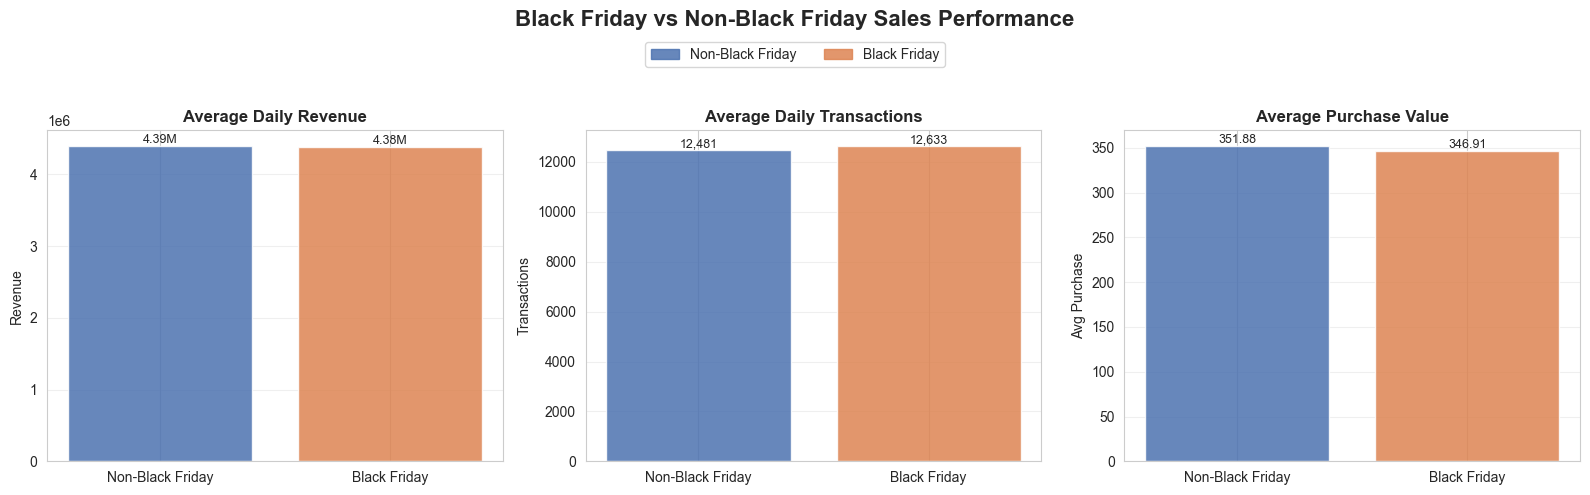

In [11]:
bf_summary = (
    df.assign(
        period=np.where(
            df['is_black_friday'] == 1,
            'Black Friday',
            'Non-Black Friday'
        )
    )
    .groupby('period')
    .agg(
        transactions=('transaction_id', 'count'),
        revenue=('purchase_amount', 'sum'),
        avg_purchase=('purchase_amount', 'mean')
    )
    .reset_index()
)

bf_summary['days'] = bf_summary['period'].map({
    'Black Friday': 1,
    'Non-Black Friday': df.loc[
        df['is_black_friday'] == 0,
        'date'
    ].dt.date.nunique()
})

bf_summary['avg_daily_revenue'] = (
    bf_summary['revenue'] / bf_summary['days']
)

bf_summary['avg_daily_transactions'] = (
    bf_summary['transactions'] / bf_summary['days']
)

period_order = ['Non-Black Friday', 'Black Friday']
bf_summary['period'] = pd.Categorical(
    bf_summary['period'],
    categories=period_order,
    ordered=True
)

bf_summary = bf_summary.sort_values('period')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('avg_daily_revenue', 'Average Daily Revenue', 'Revenue'),
    ('avg_daily_transactions', 'Average Daily Transactions', 'Transactions'),
    ('avg_purchase', 'Average Purchase Value', 'Avg Purchase')
]

colors = ['#4C72B0', '#DD8452']

for ax, (metric, title, ylabel) in zip(axes, metrics):
    bars = ax.bar(
        bf_summary['period'],
        bf_summary[metric],
        color=colors,
        alpha=0.85
    )

    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()

        if metric == 'avg_daily_revenue':
            label = f'{height/1_000_000:.2f}M'
        elif metric == 'avg_daily_transactions':
            label = f'{height:,.0f}'
        else:
            label = f'{height:.2f}'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha='center',
            va='bottom',
            fontsize=9
        )

fig.suptitle(
    'Black Friday vs Non-Black Friday Sales Performance',
    fontsize=16,
    weight='bold'
)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[0], alpha=0.85),
    plt.Rectangle((0, 0), 1, 1, color=colors[1], alpha=0.85)
]

fig.legend(
    handles,
    period_order,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Black Friday vs Non Black Friday Sales Performance.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Black Friday increased transaction activity but did not lead to stronger revenue performance. Although Black Friday recorded more transactions than the non-Black Friday daily average, its average daily revenue was slightly lower.

This difference appears to be driven by a lower average purchase value on Black Friday. Customers purchased more frequently, but the average transaction value was smaller, which limited the overall revenue impact.

Overall, Black Friday affected sales performance more through transaction volume than transaction value. This suggests that the promotion may have encouraged more purchases, but not necessarily higher-value purchases.

### 3.3 Which product categories contributed the most to revenue?

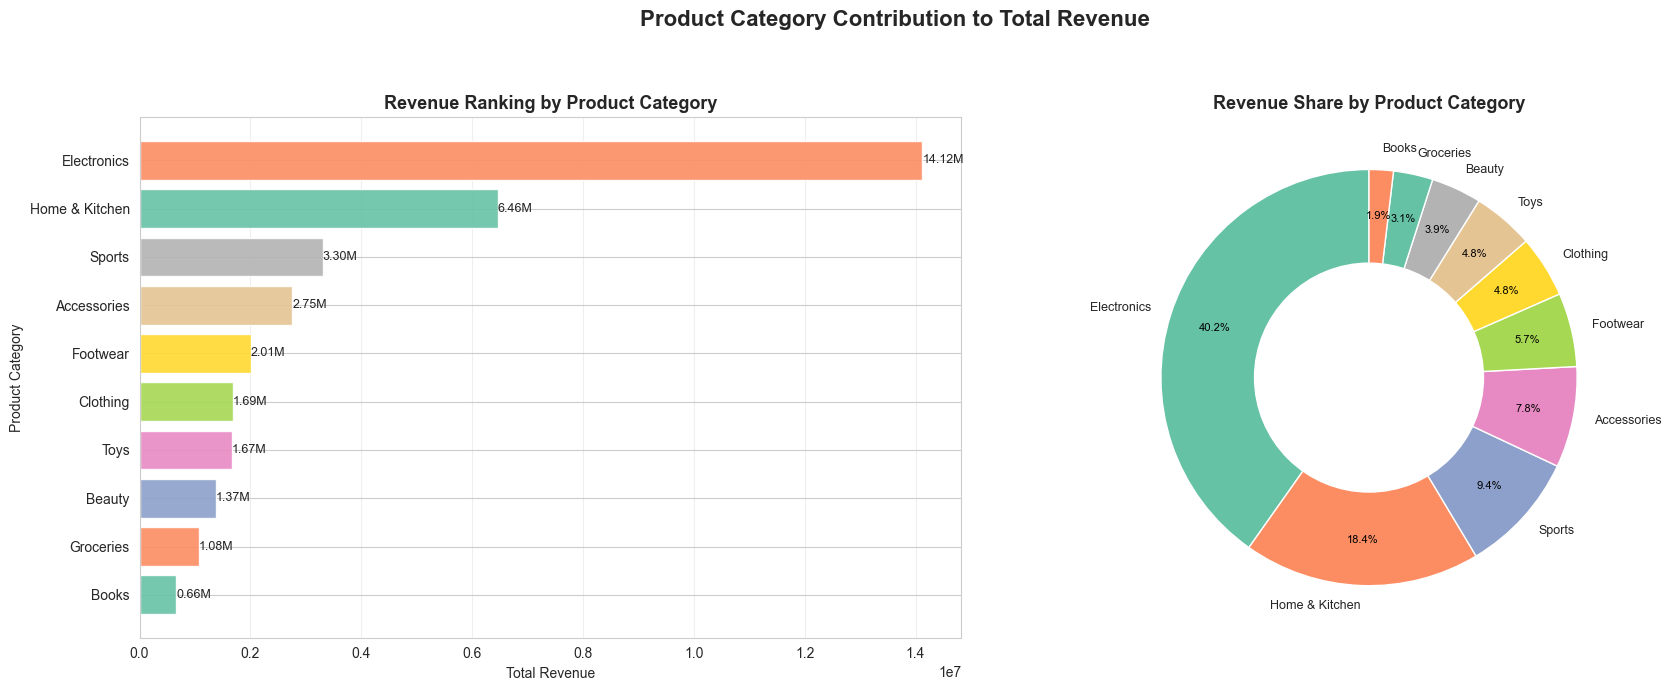

In [12]:
category_revenue = (
    df.groupby('product_category')
      .agg(
          transactions=('transaction_id', 'count'),
          revenue=('purchase_amount', 'sum'),
          avg_purchase=('purchase_amount', 'mean')
      )
      .reset_index()
      .sort_values('revenue', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = sns.color_palette('Set2', len(category_revenue))

bars = axes[0].barh(
    category_revenue['product_category'],
    category_revenue['revenue'],
    color=colors,
    alpha=0.9,
    label='Revenue'
)

axes[0].set_title(
    'Revenue Ranking by Product Category',
    fontsize=13,
    weight='bold'
)
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Product Category')

for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width/1_000_000:.2f}M',
        va='center',
        ha='left',
        fontsize=9
    )

axes[0].grid(True, axis='x', alpha=0.3)

pie_data = category_revenue.sort_values('revenue', ascending=False)

wedges, texts, autotexts = axes[1].pie(
    pie_data['revenue'],
    labels=pie_data['product_category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(pie_data)),
    pctdistance=0.78
)

centre_circle = plt.Circle(
    (0, 0),
    0.55,
    fc='white'
)

axes[1].add_artist(centre_circle)

axes[1].set_title(
    'Revenue Share by Product Category',
    fontsize=13,
    weight='bold'
)

for text in texts:
    text.set_fontsize(9)

for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('black')

fig.suptitle(
    'Product Category Contribution to Total Revenue',
    fontsize=16,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Product Category Contribution to Total Revenue.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Electronics was the strongest revenue contributor during the promotional period, generating around 14.12M in total revenue and accounting for about 40.2% of overall sales. This makes Electronics the dominant product category by a wide margin.

Home & Kitchen ranked second with around 6.46M in revenue, contributing about 18.4% of total sales. Together, Electronics and Home & Kitchen contributed more than half of total revenue, indicating that sales performance was highly concentrated in a few key categories.

Other categories such as Sports, Accessories, Footwear, Clothing, Toys, Beauty, Groceries, and Books contributed smaller shares individually. This suggests that while the dataset covers a broad range of product categories, overall revenue was mainly driven by high-performing categories, especially Electronics.

### 3.4 Which customer segments generated the highest revenue?

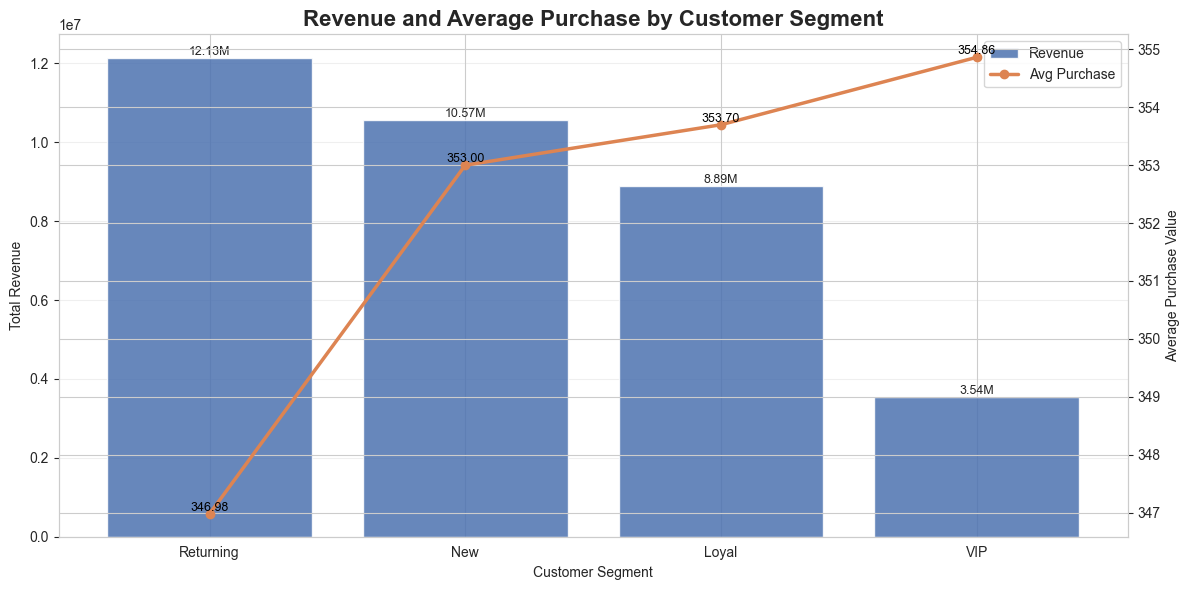

In [13]:
segment_summary = (
    df.groupby('customer_segment')
      .agg(
          transactions=('transaction_id', 'count'),
          revenue=('purchase_amount', 'sum'),
          avg_purchase=('purchase_amount', 'mean')
      )
      .reset_index()
      .sort_values('revenue', ascending=False)
)

x_pos = np.arange(len(segment_summary))

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    x_pos,
    segment_summary['revenue'],
    color='#4C72B0',
    alpha=0.85,
    label='Revenue'
)

ax1.set_title(
    'Revenue and Average Purchase by Customer Segment',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Customer Segment')
ax1.set_ylabel('Total Revenue')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(segment_summary['customer_segment'])

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1_000_000:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    segment_summary['avg_purchase'],
    marker='o',
    color='#DD8452',
    linewidth=2.5,
    label='Avg Purchase'
)

ax2.set_ylabel('Average Purchase Value')

for x, y in zip(x_pos, segment_summary['avg_purchase']):
    ax2.text(
        x,
        y,
        f'{y:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right'
)

ax1.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Revenue and Average Purchase by Customer Segment.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Returning customers generated the highest total revenue, reaching around 12.13M. This indicates that customers who had purchased before contributed the most to overall sales during the promotional period.

However, VIP customers had the highest average transaction value, at around 354.86, even though their total revenue was the lowest. This suggests that VIP customers made fewer transactions overall, but each transaction tended to have a higher value.

Overall, customer segment performance shows two different patterns. Returning customers were the main revenue driver by total contribution, while VIP customers were the most valuable on a per-transaction basis.

### 3.5 How do discount levels relate to revenue and quantity sold?

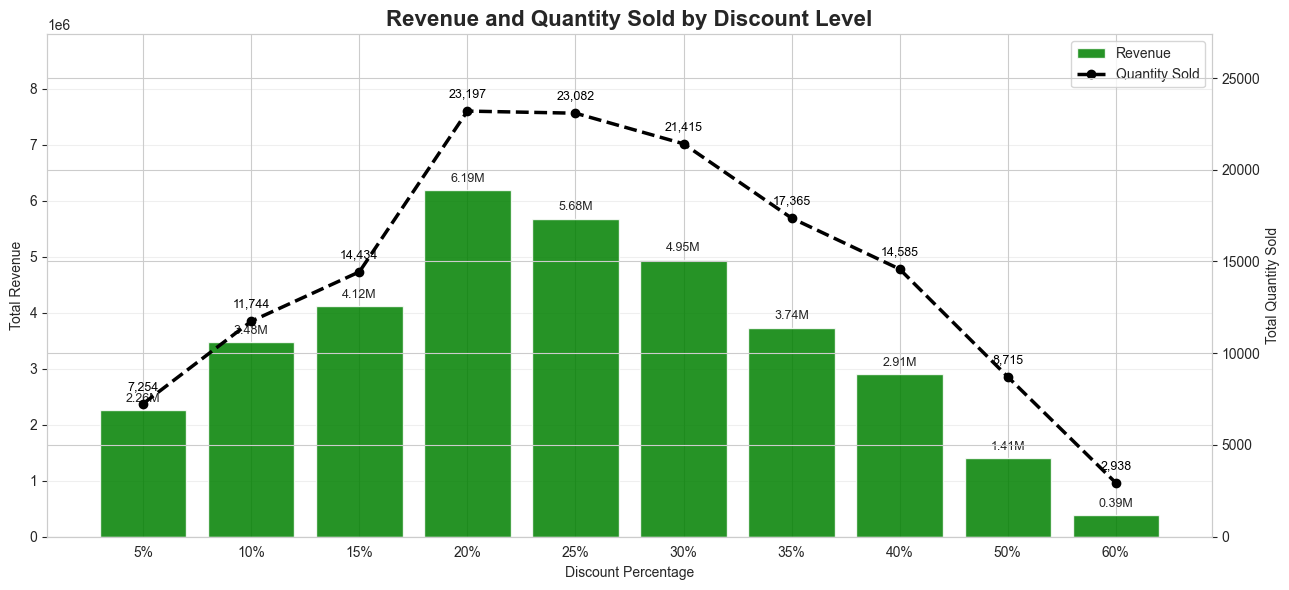

In [14]:
discount_summary = (
    df.groupby('discount_pct')
      .agg(
          transactions=('transaction_id', 'count'),
          revenue=('purchase_amount', 'sum'),
          quantity_sold=('quantity', 'sum'),
          avg_purchase=('purchase_amount', 'mean')
      )
      .reset_index()
      .sort_values('discount_pct')
)

x_pos = np.arange(len(discount_summary))

fig, ax1 = plt.subplots(figsize=(13, 6))

bars = ax1.bar(
    x_pos,
    discount_summary['revenue'],
    color='green',
    alpha=0.85,
    label='Revenue'
)

ax1.set_title(
    'Revenue and Quantity Sold by Discount Level',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Discount Percentage')
ax1.set_ylabel('Total Revenue')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    discount_summary['discount_pct'].astype(str) + '%'
)

ax1.set_ylim(0, discount_summary['revenue'].max() * 1.45)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + discount_summary['revenue'].max() * 0.015,
        f'{height/1_000_000:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    discount_summary['quantity_sold'],
    color='black',
    linewidth=2.5,
    label='Quantity Sold',
    linestyle='--',
    marker='o'
)

ax2.set_ylabel('Total Quantity Sold')
ax2.set_ylim(0, discount_summary['quantity_sold'].max() * 1.18)

for x, y in zip(x_pos, discount_summary['quantity_sold']):
    ax2.text(
        x,
        y + discount_summary['quantity_sold'].max() * 0.025,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right'
)

ax1.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Revenue and Quantity Sold by Discount Level.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Revenue and quantity sold were highest at moderate discount levels. The 20% discount generated the highest revenue, reaching around 6.19M, while the 20% and 25% discount levels recorded the highest quantity sold, with more than 23,000 items sold.

Higher discounts did not always lead to stronger sales performance. Revenue and quantity sold declined at higher discount levels, especially at 50% and 60%. This suggests that extreme discounts were not the main driver of total sales in this dataset.

Overall, moderate discounts between 20% and 30% appeared to contribute the most to revenue and quantity sold.

### 3.6 How does discount percentage relate to purchase amount?

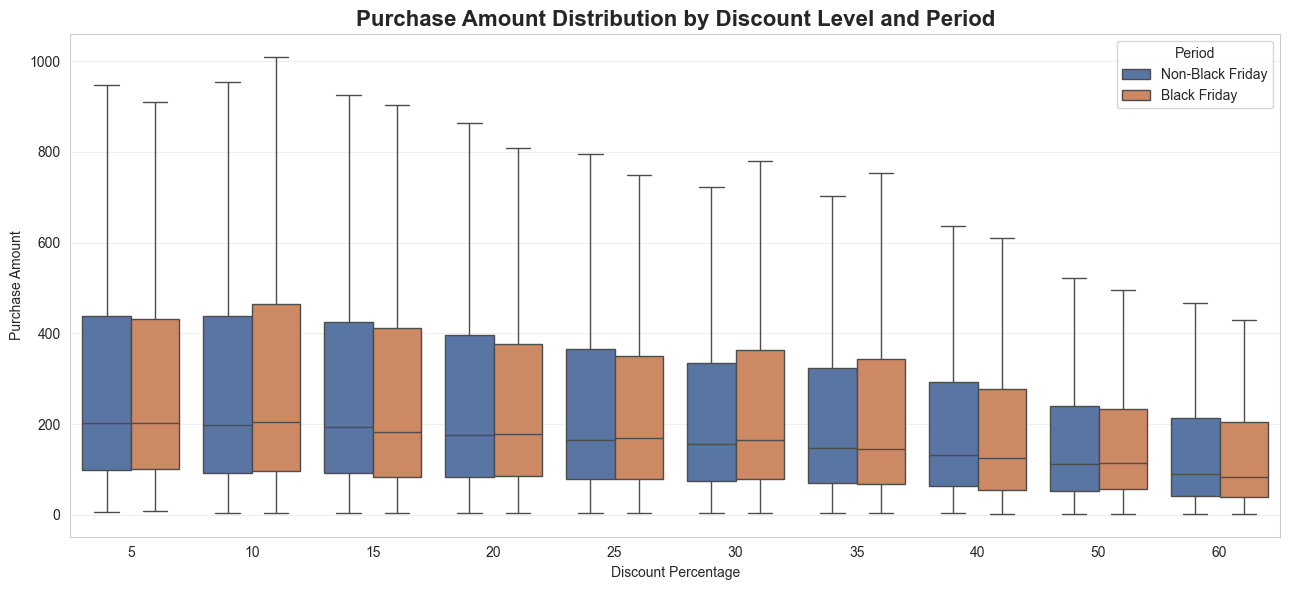

In [15]:
plot_df = df.copy()

plot_df['period'] = np.where(
    plot_df['is_black_friday'] == 1,
    'Black Friday',
    'Non-Black Friday'
)

fig, ax = plt.subplots(figsize=(13, 6))

sns.boxplot(
    data=plot_df,
    x='discount_pct',
    y='purchase_amount',
    hue='period',
    hue_order=['Non-Black Friday', 'Black Friday'],
    showfliers=False,
    palette={
        'Non-Black Friday': '#4C72B0',
        'Black Friday': '#DD8452'
    },
    ax=ax
)

ax.set_title(
    'Purchase Amount Distribution by Discount Level and Period',
    fontsize=16,
    weight='bold'
)
ax.set_xlabel('Discount Percentage')
ax.set_ylabel('Purchase Amount')

ax.legend(
    title='Period',
    loc='upper right'
)

ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Purchase Amount Distribution by Discount Level and Period.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Purchase amount generally decreased as discount levels increased. Lower discount levels showed higher and wider transaction value ranges, while higher discount levels such as 50% and 60% had lower purchase amount distributions.

Black Friday and non-Black Friday transactions showed similar distribution patterns across most discount levels. This indicates that the relationship between discount level and purchase amount was relatively consistent across both periods.

Overall, higher discounts were associated with smaller transaction values, suggesting that large discounts may have been applied more often to lower-value purchases or lower-priced products.

### 3.7 What are the peak purchasing hours during the promotional period?

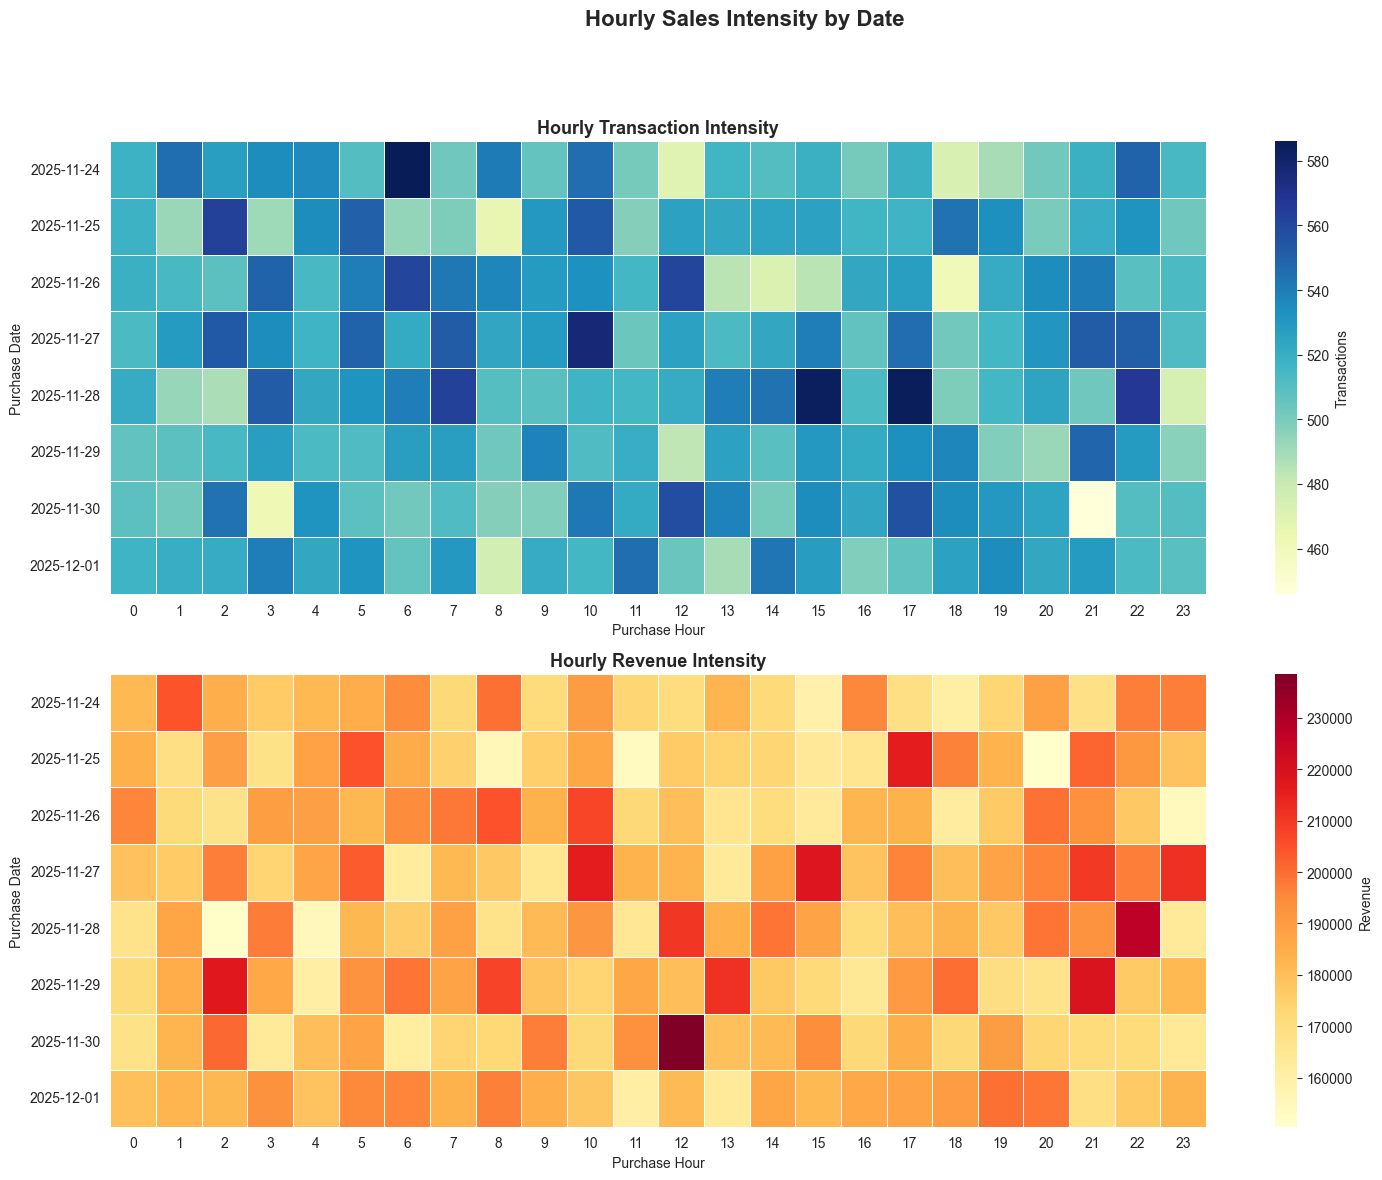

In [16]:
hourly_summary = (
    df.assign(
        purchase_day=df['date'].dt.strftime('%Y-%m-%d')
    )
    .groupby(['purchase_day', 'purchase_hour'])
    .agg(
        transactions=('transaction_id', 'count'),
        revenue=('purchase_amount', 'sum')
    )
    .reset_index()
)

transaction_heatmap = hourly_summary.pivot(
    index='purchase_day',
    columns='purchase_hour',
    values='transactions'
)

revenue_heatmap = hourly_summary.pivot(
    index='purchase_day',
    columns='purchase_hour',
    values='revenue'
)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.heatmap(
    transaction_heatmap,
    cmap='YlGnBu',
    linewidths=0.5,
    annot=False,
    cbar_kws={'label': 'Transactions'},
    ax=axes[0]
)

axes[0].set_title(
    'Hourly Transaction Intensity',
    fontsize=13,
    weight='bold'
)
axes[0].set_xlabel('Purchase Hour')
axes[0].set_ylabel('Purchase Date')

sns.heatmap(
    revenue_heatmap,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=False,
    cbar_kws={'label': 'Revenue'},
    ax=axes[1]
)

axes[1].set_title(
    'Hourly Revenue Intensity',
    fontsize=13,
    weight='bold'
)
axes[1].set_xlabel('Purchase Hour')
axes[1].set_ylabel('Purchase Date')

fig.suptitle(
    'Hourly Sales Intensity by Date',
    fontsize=16,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Hourly Sales Intensity by Date.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

Transaction activity was spread fairly evenly across hours and dates, with no single hour consistently dominating the entire promotional period. However, several stronger transaction periods appeared around morning to afternoon hours, especially between 10:00 and 17:00 on selected dates.

Revenue intensity showed a more uneven pattern than transaction volume. Some hours generated noticeably higher revenue even when transaction intensity was not always the highest, suggesting that certain time periods had higher-value purchases rather than simply more transactions.

Overall, purchase timing influenced sales performance, but the effect was not concentrated in one fixed peak hour. Sales activity remained active throughout the day, while revenue spikes were more dependent on high-value transactions at specific hours.

### 3.8 How do the existing customer segments perform when analyzed using RFM (Recency, Frequency, Monetary) metrics?

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_8948\2175675249.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_segment', y='avg_recency', ax=axes[0], palette='viridis')
C:\Users\FATHIR\AppData\Local\Temp\ipykernel_8948\2175675249.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_segment', y='avg_frequency', ax=axes[1], palette='viridis')
C:\Users\FATHIR\AppData\Local\Temp\ipykernel_8948\2175675249.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summar

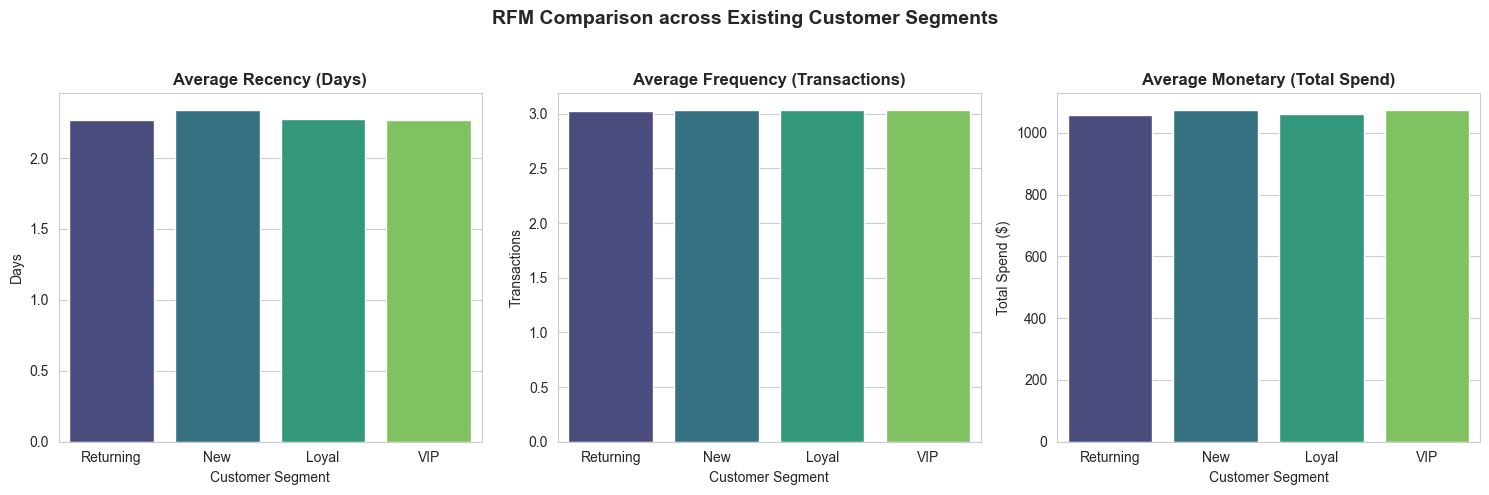

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary
2,Returning,11514,2.265905,3.028748,1056.332144
1,New,9870,2.338733,3.033333,1072.955326
0,Loyal,8369,2.276930,3.029633,1062.152268
3,VIP,3244,2.270692,3.031134,1073.921381


In [17]:
# 1. Calculate customer-level RFM metrics
max_date = df['date'].max()
rfm = (
    df.groupby('customer_id')
      .agg(
          recency=('date', lambda x: (max_date - x.max()).total_seconds() / 86400.0),
          frequency=('transaction_id', 'count'),
          monetary=('purchase_amount', 'sum')
      )
      .reset_index()
)

# 2. Get each customer's segment from their latest transaction chronologically
latest_tx = df.sort_values('date').groupby('customer_id').last().reset_index()
customer_segments = latest_tx[['customer_id', 'customer_segment']]

# 3. Merge RFM metrics with the customer segment labels
rfm_cust = rfm.merge(customer_segments, on='customer_id')

# 4. Group by customer segment and calculate average RFM metrics
segment_summary = (
    rfm_cust.groupby('customer_segment')
            .agg(
                customer_count=('customer_id', 'count'),
                avg_recency=('recency', 'mean'),
                avg_frequency=('frequency', 'mean'),
                avg_monetary=('monetary', 'mean')
            )
            .reset_index()
            .sort_values(by='customer_count', ascending=False)
)

# 5. Visualizations: Plot RFM metrics side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency Plot
sns.barplot(data=segment_summary, x='customer_segment', y='avg_recency', ax=axes[0], palette='viridis')
axes[0].set_title('Average Recency (Days)', fontsize=12, weight='bold')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Days')

# Frequency Plot
sns.barplot(data=segment_summary, x='customer_segment', y='avg_frequency', ax=axes[1], palette='viridis')
axes[1].set_title('Average Frequency (Transactions)', fontsize=12, weight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Transactions')

# Monetary Plot
sns.barplot(data=segment_summary, x='customer_segment', y='avg_monetary', ax=axes[2], palette='viridis')
axes[2].set_title('Average Monetary (Total Spend)', fontsize=12, weight='bold')
axes[2].set_xlabel('Customer Segment')
axes[2].set_ylabel('Total Spend ($)')

fig.suptitle('RFM Comparison across Existing Customer Segments', fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save plot to plots folder as per your notebook convention
os.makedirs('plots', exist_ok=True)
plt.savefig(os.path.join('plots', 'RFM Comparison across Existing Customer Segments.png'), dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

segment_summary


### Insight

- **Identical RFM Behaviors**: Despite having distinct segment names (*Loyal*, *New*, *Returning*, and *VIP*), the average Recency (~2.3 days), Frequency (~3.03 purchases), and Monetary value (~1,058 to 1,072 total spend) are virtually identical across all groups. 
- **Synthetic Data Characteristics**: In real-world retail datasets, VIP and Loyal customers typically display significantly lower recency, higher purchase frequency, and higher monetary value compared to New or Returning customers. The uniform RFM distribution across these segments strongly confirms that this dataset is synthetic or simulated.
- **Segment Validity**: For future predictive modeling or targeted campaigns, the existing `customer_segment` labels in this dataset should not be relied upon as indicators of actual historical purchase behavior, as they do not reflect distinct transaction patterns.

### 3.9 Which cities and demographic groups contributed the most to transactions and revenue?

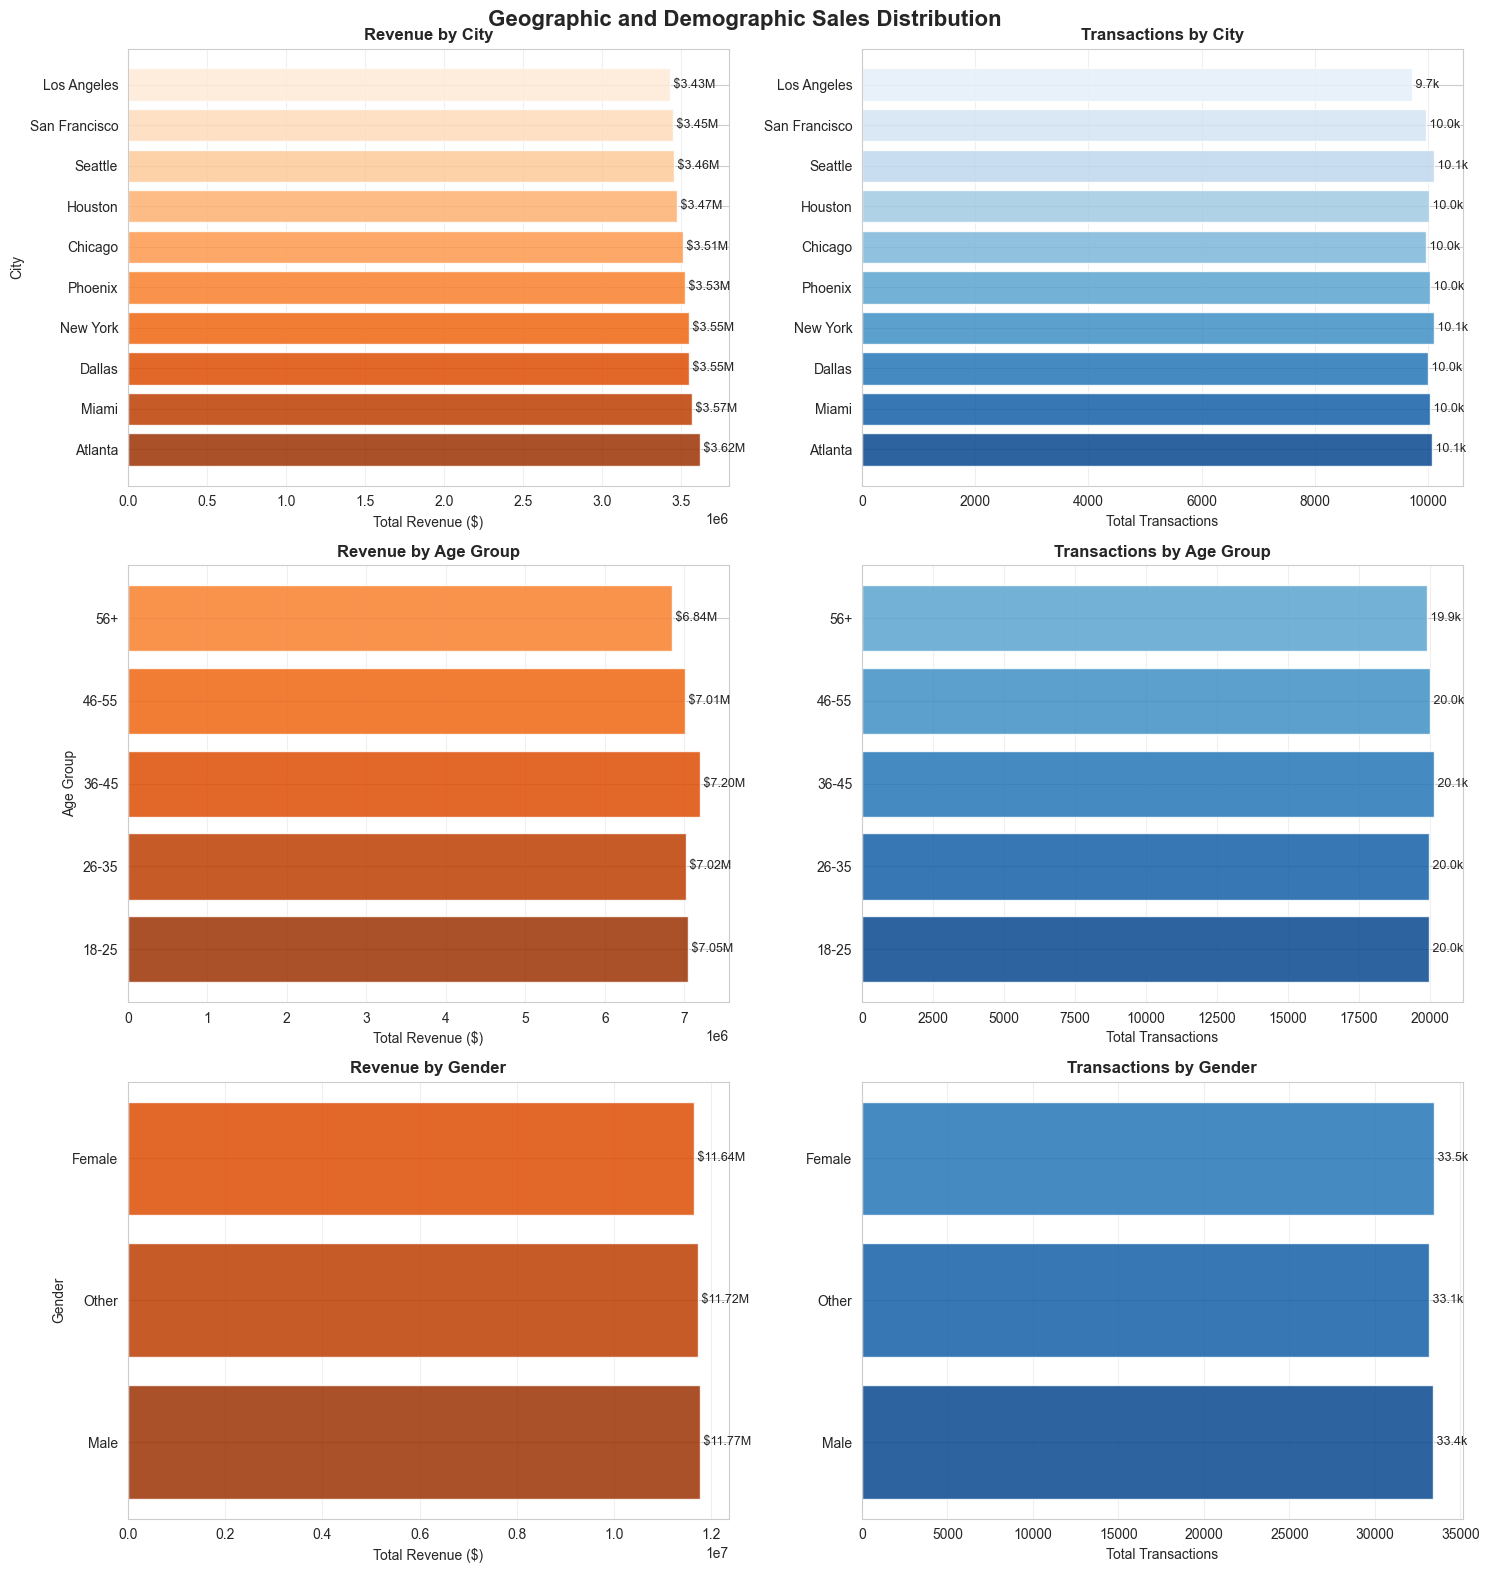

In [18]:
# Grouping data by city, age group, and gender
city_df = df.groupby('city').agg(
    revenue=('purchase_amount', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index().sort_values(by='revenue', ascending=False)

age_df = df.groupby('age_group').agg(
    revenue=('purchase_amount', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index().sort_values(by='age_group')

gender_df = df.groupby('gender').agg(
    revenue=('purchase_amount', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index().sort_values(by='revenue', ascending=False)

# Creating the subplot structure (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(15, 16))

# Define cohesive color palettes
rev_palette = sns.color_palette("Oranges_r", n_colors=10)
tr_palette = sns.color_palette("Blues_r", n_colors=10)

# --- Row 1: City ---
# Revenue
bars_city_rev = axes[0, 0].barh(city_df['city'], city_df['revenue'], color=rev_palette[:len(city_df)], alpha=0.85)
axes[0, 0].set_title('Revenue by City', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Total Revenue ($)')
axes[0, 0].set_ylabel('City')
axes[0, 0].grid(True, axis='x', alpha=0.3)
for bar in bars_city_rev:
    width = bar.get_width()
    axes[0, 0].text(width, bar.get_y() + bar.get_height()/2, f' ${width/1e6:.2f}M', 
                    va='center', ha='left', fontsize=9)

# Transactions
bars_city_tr = axes[0, 1].barh(city_df['city'], city_df['transactions'], color=tr_palette[:len(city_df)], alpha=0.85)
axes[0, 1].set_title('Transactions by City', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Total Transactions')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True, axis='x', alpha=0.3)
for bar in bars_city_tr:
    width = bar.get_width()
    axes[0, 1].text(width, bar.get_y() + bar.get_height()/2, f' {width/1e3:.1f}k', 
                    va='center', ha='left', fontsize=9)

# --- Row 2: Age Group ---
# Revenue
bars_age_rev = axes[1, 0].barh(age_df['age_group'], age_df['revenue'], color=rev_palette[:len(age_df)], alpha=0.85)
axes[1, 0].set_title('Revenue by Age Group', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Total Revenue ($)')
axes[1, 0].set_ylabel('Age Group')
axes[1, 0].grid(True, axis='x', alpha=0.3)
for bar in bars_age_rev:
    width = bar.get_width()
    axes[1, 0].text(width, bar.get_y() + bar.get_height()/2, f' ${width/1e6:.2f}M', 
                    va='center', ha='left', fontsize=9)

# Transactions
bars_age_tr = axes[1, 1].barh(age_df['age_group'], age_df['transactions'], color=tr_palette[:len(age_df)], alpha=0.85)
axes[1, 1].set_title('Transactions by Age Group', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Total Transactions')
axes[1, 1].set_ylabel('')
axes[1, 1].grid(True, axis='x', alpha=0.3)
for bar in bars_age_tr:
    width = bar.get_width()
    axes[1, 1].text(width, bar.get_y() + bar.get_height()/2, f' {width/1e3:.1f}k', 
                    va='center', ha='left', fontsize=9)

# --- Row 3: Gender ---
# Revenue
bars_gen_rev = axes[2, 0].barh(gender_df['gender'], gender_df['revenue'], color=rev_palette[:len(gender_df)], alpha=0.85)
axes[2, 0].set_title('Revenue by Gender', fontsize=12, weight='bold')
axes[2, 0].set_xlabel('Total Revenue ($)')
axes[2, 0].set_ylabel('Gender')
axes[2, 0].grid(True, axis='x', alpha=0.3)
for bar in bars_gen_rev:
    width = bar.get_width()
    axes[2, 0].text(width, bar.get_y() + bar.get_height()/2, f' ${width/1e6:.2f}M', 
                    va='center', ha='left', fontsize=9)

# Transactions
bars_gen_tr = axes[2, 1].barh(gender_df['gender'], gender_df['transactions'], color=tr_palette[:len(gender_df)], alpha=0.85)
axes[2, 1].set_title('Transactions by Gender', fontsize=12, weight='bold')
axes[2, 1].set_xlabel('Total Transactions')
axes[2, 1].set_ylabel('')
axes[2, 1].grid(True, axis='x', alpha=0.3)
for bar in bars_gen_tr:
    width = bar.get_width()
    axes[2, 1].text(width, bar.get_y() + bar.get_height()/2, f' {width/1e3:.1f}k', 
                    va='center', ha='left', fontsize=9)

fig.suptitle('Geographic and Demographic Sales Distribution', fontsize=16, weight='bold')
plt.tight_layout()

# Save the plot to matching folder as per convention
os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Geographic and Demographic Sales Distribution.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

### Insight

- **Uniform Regional Contribution**: Sales across all 10 cities are highly symmetrical, with each city contributing approximately 10,000 transactions and generating between $3.43M to $3.61M in revenue. No single city dominates the geographical landscape.
- **Symmetric Demographics**: The revenue and transaction distribution across the 5 age groups is virtually identical (~20k transactions and ~$7M per group). Similarly, the gender distribution is extremely balanced.
- **Simulated Data Characteristics**: In real-world retail operations, demographic groups and cities display highly distinct and unequal spending behaviors, purchasing power, and preferences. The flat and uniform distributions observed here strongly reinforce the conclusion that this dataset is synthetic and artificially simulated.

### 3.10 What payment methods were used most frequently, and did they impact transaction values?


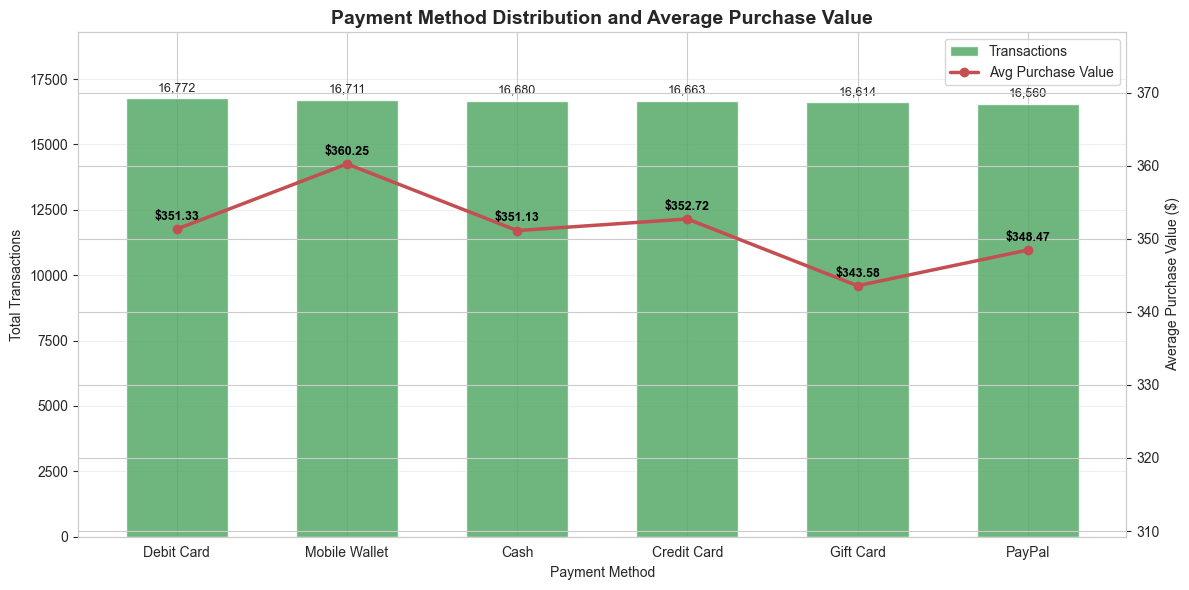

In [19]:
# Process Payment Method aggregations
pm_df = df.groupby('payment_method').agg(
    transactions=('transaction_id', 'count'),
    revenue=('purchase_amount', 'sum'),
    avg_purchase=('purchase_amount', 'mean')
).reset_index().sort_values(by='transactions', ascending=False)

x_pos = np.arange(len(pm_df))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for transaction counts (Left Y-axis)
bars = ax1.bar(
    x_pos,
    pm_df['transactions'],
    color='#55A868',
    alpha=0.85,
    label='Transactions',
    width=0.6
)

ax1.set_title('Payment Method Distribution and Average Purchase Value', fontsize=14, weight='bold')
ax1.set_xlabel('Payment Method')
ax1.set_ylabel('Total Transactions')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(pm_df['payment_method'])
ax1.set_ylim(0, pm_df['transactions'].max() * 1.15)

# Annotate transaction count on top of the bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + pm_df['transactions'].max() * 0.01,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Line plot for average purchase value (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(
    x_pos,
    pm_df['avg_purchase'],
    color='#C44E52',
    linewidth=2.5,
    marker='o',
    label='Avg Purchase Value'
)
ax2.set_ylabel('Average Purchase Value ($)')
ax2.set_ylim(pm_df['avg_purchase'].min() * 0.9, pm_df['avg_purchase'].max() * 1.05)

# Annotate line markers with average purchase values
for x, y in zip(x_pos, pm_df['avg_purchase']):
    ax2.text(
        x,
        y + (pm_df['avg_purchase'].max() - pm_df['avg_purchase'].min()) * 0.05,
        f'${y:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black',
        weight='bold'
    )

# Set Grid and combined legend
ax1.grid(True, axis='y', alpha=0.3)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()

# Save the plot
os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', 'Payment Method Popularity and Purchase Value.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()
